## Energy consumption of two opposing vessels passing a lock
In this notebook, we simulate a lock complex on a network. We model two opposing directed vessels that have to pass the complex. Hence, when one vessel is being levelled, the other vessel has to wait. We quantify energy consumption with the Energy Module.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import numpy as np
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.utils import create_object
from opentnsim.graph import mixins as graph_module
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.output import HasOutput
from opentnsim.energy.mixins import ConsumesEnergy
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
)

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

# package(s) needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


#### 0. Create environment
We create an environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
We create a simple graph, just like notebooks 201, 202, and 203.

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087') #equidistant WGS84 in meters
wgs84rad = pyproj.CRS('4326') #radial WGS84 (used in GPS)

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.Graph()

# add nodes
geometry_m = Point(-5000,0)
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_node('0',geometry=geometry) #we need to have a geometry in WGS84
geometry_m = Point(5000,0)
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_node('1',geometry=geometry) #we need to have a geometry in WGS84

# add edges
geometry_m = LineString([Point(-5000, 0),Point(5000, 0)])
geometry = transform(wgs84eqd_to_wgs84rad, geometry_m)
graph.add_edge('0','1', geometry = geometry, weight=1, length_m=10000, GeneralDepth = 6.5) #we need to have a geometry in WGS84 and a length in meters

# add graph to environment
env.graph = graph

We plot the graph

In [4]:
graph_module.plot_graph(graph)

#### 1+ Adding infrastructure
We add the lock complex

In [5]:
#We use approach a)
lock_chamber = IsLockChamber(env=env,
                             lock_length = 400,
                             lock_width = 50,
                             lock_depth = 10,
                             name='Lock',      
                             edge = ('0','1'),
                             distance_from_start_node_to_lock_gate_A = 4800.,
                             distance_from_end_node_to_lock_gate_B = 4800.)

In [6]:
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   distance_from_edge_start = 0) #Waiting area A will be located on node 1

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   distance_from_edge_start = 0) #Waiting area B will be located on node 1

In [7]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create agents according to earlier notebooks.

In [8]:
Vessel = create_object(
    "Vessel",
    (
        Identifiable,               # allows to give the object a name and a random ID,
        VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)      
        Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        LockComplexTraversable,     # allows to interact with a lock
        ConsumesEnergy,             # allows to calculate energy consumption
        ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        HasMultiDiGraph,            # allow to operate on a graph that can include parallel edges from and to the same nodes
        HasOutput,                  # allow additional output to be stored
        
    ),
)

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

We create two vessels with opposing directions

In [10]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00'), # required by PassesLockComplex
    "safety_margin": 0.2,       
    "h_squat": False,           
    "P_installed": 1750.0, 
    "P_tot_given": None, 
    "bulbous_bow": False, 
    "karpov_correction": True, 
    "P_hotel_perc": 0.05, 
    "P_hotel": None,
    "x": 2,
    "L_w": 3.0 ,
    "C_B": 0.85,
    "C_year": 1990,
}  
vessel_1 = Vessel(**data_vessel_1)

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 5,                                              # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00'), # required by PassesLockComplex
    "safety_margin": 0.2,       
    "h_squat": False,           
    "P_installed": 1750.0, 
    "P_tot_given": None, 
    "bulbous_bow": False, 
    "karpov_correction": True, 
    "P_hotel_perc": 0.05, 
    "P_hotel": None,
    "x": 2,
    "L_w": 3.0 ,
    "C_B": 0.85,
    "C_year": 1990,
}  
vessel_2 = Vessel(**data_vessel_2)

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2));

#### 3. Run simulation
We run the simulation

In [11]:
env.run()

#### 4. Inspect output

##### Time-distance diagram
We confirm the vessel-infrastructure behaviour.

In [12]:
# eventtable for only vessels,
df_eventtable = opentnsim.core.logutils.logbook2eventtable([vessel_1, vessel_2, lock_chamber])
generate_vessel_gantt_chart(df_eventtable)

In [13]:
from opentnsim.graph.utils import get_trajectory_between_locations, find_closest_node, find_closest_edge
from shapely.ops import split, linemerge, snap
from shapely.geometry import MultiPoint, MultiLineString

def get_unique_geometries(row):
    start = row['start location']
    stop = row['stop location']
    if start == stop:
        return Point(start)
    else:
        return LineString([start, stop])

def determine_if_geometry_on_node(row, graph):
    geometry = row['geometry']
    start_location = row['start location']
    stop_location = row['stop location']
    node_start = find_closest_node(graph, start_location)
    node_stop = find_closest_node(graph, stop_location)
    start_location_on_node = False
    stop_location_on_node = False
    if graph.nodes[node_start]['geometry'] == start_location:
        start_location_on_node = True
    if graph.nodes[node_stop]['geometry'] == stop_location:
        stop_location_on_node = True
    return start_location_on_node, stop_location_on_node


def split_edge_in_graph(G, u, v, segments):
    """
    Replace edge (u, v) with multiple segment edges.
    
    segments: list of LineStrings (ordered!)
    """
    G_new = G.copy()

    # Get original edge data
    edge_data = G.edges[u, v].copy()

    # Remove original edge
    G_new.remove_edge(u, v)

    # Helper: create node id from coordinate
    def node_id(coord):
        return tuple(coord)  # or str(coord) if needed

    # Build nodes + edges
    prev_node = u

    for i, seg in enumerate(segments):
        start = seg.coords[0]
        end = seg.coords[-1]

        # Add start node if needed
        if prev_node == u:
            current_start = u
        else:
            current_start = node_id(start)
            G_new.add_node(current_start, x=start[0], y=start[1], geometry=Point(start))

        # Add end node
        if i == len(segments) - 1:
            current_end = v
        else:
            current_end = node_id(end)
            G_new.add_node(current_end, x=end[0], y=end[1], geometry=Point(end))

        # Add new edge
        G_new.add_edge(current_start, current_end, weight=1, geometry = seg)

        prev_node = current_end

    return G_new

def copy_graph_and_remove_information(graph, keep_edge_columns=['weigth','geometry'], keep_node_columns=['geometry']):
    graph_new = graph.copy()
    for n, data in graph_new.nodes(data=True):
        keys = list(data.keys())
        for k in keys:
            if k not in keep_node_columns:
                del data[k]
    for u, v, data in graph_new.edges(data=True):
        keys = list(data.keys())
        for k in keys:
            if k not in keep_node_columns:
                del data[k]  
    return graph_new

graph_new = copy_graph_and_remove_information(env.graph)
graph_new = graph_new.to_undirected()
df_eventtable = opentnsim.core.logutils.logbook2eventtable([vessel_1, vessel_2])
df_eventtable['geometry'] = df_eventtable.apply(get_unique_geometries, axis=1)
df = pd.DataFrame(df_eventtable.apply(determine_if_geometry_on_node, graph=graph_new, axis=1), columns=['result'])
df_eventtable[['start_location_on_node', 'stop_location_on_node']] = pd.DataFrame(df['result'].tolist(), index=df.index)
unique_locations = pd.unique(pd.concat([df_eventtable[~df_eventtable.start_location_on_node]['start location'],
                                        df_eventtable[~df_eventtable.start_location_on_node]['stop location']]))
edge_splits = {}
for unique_location in unique_locations:
    edge = find_closest_edge(env.graph, unique_location)
    if edge not in edge_splits.keys():
        edge_splits[edge] = []
    edge_splits[edge].append(unique_location)

for edge, points in edge_splits.items():
    edge_geometry = graph.edges[edge]['geometry']
    splitter = snap(MultiPoint(points), edge_geometry, tolerance=1e-6)
    segments = split(edge_geometry, splitter)
    graph_new = split_edge_in_graph(graph_new, edge[0], edge[1], segments.geoms)

df_eventtable['start_node'] = df_eventtable['start location'].apply(lambda x: find_closest_node(graph_new, x))
df_eventtable['stop_node'] = df_eventtable['stop location'].apply(lambda x: find_closest_node(graph_new, x))
df_eventtable['route'] = df_eventtable.apply(lambda x: nx.dijkstra_path(graph_new, x.start_node, x.stop_node),axis=1)
df_eventtable['edges'] = df_eventtable['route'].apply(lambda r: list(zip(r[:-1], r[1:])))

def update_locations(row):
    geom = row['geometry']
    if isinstance(geom, LineString):
        row['start location'] = Point(geom.coords[0])
        row['stop location']  = Point(geom.coords[-1])
    elif isinstance(geom, Point):
        row['start location'] = geom
        row['stop location']  = geom
    return row
    
def expand_row_by_edges(row, graph):
    """
    Expands a row into multiple rows if it has multiple edges.
    Distance and duration are split proportionally.
    """
    edges = row['edges']
    if not edges or len(edges) <= 1:
        return [row]
    
    # Get edge lengths
    edge_lengths = []
    edge_geoms = []
    for edge in edges:
        u, v = edge
        geom = graph.edges[edge]['geometry']
        if isinstance(geom, LineString):
            length = geom.length
        else:
            # fallback: compute from coords
            length = LineString([u, v]).length
        edge_lengths.append(length)
        edge_geoms.append(geom if isinstance(geom, LineString) else LineString([u, v]))
    
    total_length = sum(edge_lengths)
    
    # Split distance and duration proportionally
    new_rows = []
    for length, geom in zip(edge_lengths, edge_geoms):
        new_row = row.copy()
        fraction = length / total_length if total_length > 0 else 0
        new_row['distance (m)'] = row['distance (m)'] * fraction
        new_row['duration (s)'] = row['duration (s)'] * fraction
        new_row['geometry'] = geom
        # Update start_node and stop_node for this segment
        new_row['start_node'] = geom.coords[0]
        new_row['stop_node'] = geom.coords[-1]
        new_rows.append(new_row)
    
    return new_rows

expanded_rows = []

for idx, row in df_eventtable.iterrows():
    expanded_rows.extend(expand_row_by_edges(row, graph_new))

df_expanded = pd.DataFrame(expanded_rows)
df_expanded = df_expanded.reset_index(drop = True)
df_expanded = df_expanded.apply(update_locations, axis=1)
df_expanded['geometry'] = df_expanded.apply(get_unique_geometries, axis=1)
df_expanded['start_node'] = df_expanded['start location'].apply(lambda x: find_closest_node(graph_new, x))
df_expanded['stop_node'] = df_expanded['stop location'].apply(lambda x: find_closest_node(graph_new, x))
df_expanded['network_geometry'] = df_expanded.apply(lambda x: graph_new.edges[(x.start_node,x.stop_node)]['geometry'] if x.start_node != x.stop_node else graph_new.nodes[x.start_node]['geometry'], axis=1)

##### Energy consumption
To quantify the energy consumption, we have to create an event table and add energy attributes to it.

In [14]:
# # eventtable for only vessels
# df_eventtable = opentnsim.core.logutils.logbook2eventtable([vessel_1, vessel_2])

# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_expanded, [vessel_1, vessel_2])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),...,edges,network_geometry,waterdepth (m),waterway width (m),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to first lock gate,POINT (-0.0449157642059761 0),POINT (-0.001796630568239 0),2025-01-01 00:00:00,2025-01-01 00:20:00,4800.0,1200.000000,...,"[(0, (-0.0017966305682390426, 0.0))]","LINESTRING (-0.0449157642059761 0, -0.00179663...",6.5,None,0.0,1990.0,984.662385,984.662385,1750.0,328.220795
1,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to position in lock,POINT (-0.001796630568239 0),POINT (-0.0013474729261793 0),2025-01-01 00:20:00,2025-01-01 00:25:40,50.0,48.596112,...,"[((-0.0017966305682390426, 0.0), (-0.001347472...","LINESTRING (-0.001796630568239 0, -0.001347472...",6.5,None,0.0,1990.0,105.019493,105.019493,1750.0,1.417650
2,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to position in lock,POINT (-0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:20:00,2025-01-01 00:25:40,300.0,291.576674,...,"[((-0.0017966305682390426, 0.0), (-0.001347472...","LINESTRING (-0.0013474729261793 0, 0.001347472...",6.5,None,0.0,1990.0,105.019493,105.019493,1750.0,8.505898
3,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate closing,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:25:40,2025-01-01 00:30:40,0.0,300.000000,...,[],POINT (0.0013474729261793 0),6.5,None,0.0,1990.0,87.500000,87.500000,1750.0,7.291667
4,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Waiting for lock levelling,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:30:40,2025-01-01 00:40:40,0.0,600.000000,...,[],POINT (0.0013474729261793 0),6.5,None,0.0,1990.0,87.500000,87.500000,1750.0,14.583333
5,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate opening,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:40:40,2025-01-01 00:45:40,0.0,300.000000,...,[],POINT (0.0013474729261793 0),6.5,None,0.0,1990.0,87.500000,87.500000,1750.0,7.291667
6,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to second lock gate,POINT (0.0013474729261793 0),POINT (0.001796630568239 0),2025-01-01 00:45:40,2025-01-01 00:46:29,50.0,48.596113,...,"[((0.001347472926179282, 0.0), (0.001796630568...","LINESTRING (0.0013474729261793 0, 0.0017966305...",6.5,None,0.0,1990.0,105.019492,105.019492,1750.0,1.417650
7,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to lock complex exit,POINT (0.001796630568239 0),POINT (0.0449157642059761 0),2025-01-01 00:46:29,2025-01-01 01:06:29,4800.0,1200.000000,...,"[((0.0017966305682390426, 0.0), 1)]","LINESTRING (0.001796630568239 0, 0.04491576420...",6.5,None,0.0,1990.0,984.662385,984.662385,1750.0,328.220795
8,1a6423dc-5af5-4f0e-ad9c-013ff5cd7628,Vessel 2,Sailing from node 1 to node 0,Waiting for lock operation,POINT (0.0449157642059761 0),POINT (0.0449157642059761 0),2025-01-01 00:05:00,2025-01-01 00:29:34,0.0,1473.768898,...,[],POINT (0.0449157642059761 0),6.5,None,0.0,1990.0,87.500000,87.500000,1750.0,35.820772
9,1a6423dc-5af5-4f0e-ad9c-013ff5cd7628,Vessel 2,Sailing from node 1 to node 0,Sailing to first lock gate,POINT (0.0449157642059761 0),POINT (0.001796630568239 0),2025-01-01 00:29:34,2025-01-01 00:49:34,4800.0,1200.000000,...,"[(1, (0.0017966305682390426, 0.0))]","LINESTRING (0.001796630568239 0, 0.04491576420...",6.5,None,0.0,1990.0,984.662385,984.662385,1750.0,328.220795


In addition, we need to add fuel attributes to the event table:

In [15]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),geometry,start_location_on_node,stop_location_on_node,start_node,stop_node,route,edges,network_geometry,waterdepth (m),waterway width (m),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to first lock gate,POINT (-0.0449157642059761 0),POINT (-0.001796630568239 0),2025-01-01 00:00:00,2025-01-01 00:20:00,4800.0,1200.000000,"LINESTRING (-0.0449157642059761 0, -0.00179663...",True,False,0,"(-0.0017966305682390426, 0.0)","[0, (-0.0017966305682390426, 0.0)]","[(0, (-0.0017966305682390426, 0.0))]","LINESTRING (-0.0449157642059761 0, -0.00179663...",6.5,None,0.0,1990.0,984.662385,984.662385,1750.0,328.220795,74191.939085,15.456654,61.826616,235390.788551,131.288318,3306.633575,49.039748,0.027352,0.688882,196.158990,0.109407,2.755528
1,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to position in lock,POINT (-0.001796630568239 0),POINT (-0.0013474729261793 0),2025-01-01 00:20:00,2025-01-01 00:25:40,50.0,48.596112,"LINESTRING (-0.001796630568239 0, -0.001347472...",False,False,"(-0.0017966305682390426, 0.0)","(-0.001347472926179282, 0.0)","[(-0.0017966305682390426, 0.0), (-0.0013474729...","[((-0.0017966305682390426, 0.0), (-0.001347472...","LINESTRING (-0.001796630568239 0, -0.001347472...",6.5,None,0.0,1990.0,105.019493,105.019493,1750.0,1.417650,320.449479,6.408990,6.594138,1016.698803,0.567060,14.281996,20.333976,0.011341,0.285640,20.921402,0.011669,0.293892
2,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Sailing to position in lock,POINT (-0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:20:00,2025-01-01 00:25:40,300.0,291.576674,"LINESTRING (-0.0013474729261793 0, 0.001347472...",False,False,"(-0.001347472926179282, 0.0)","(0.001347472926179282, 0.0)","[(-0.0017966305682390426, 0.0), (-0.0013474729...","[((-0.0017966305682390426, 0.0), (-0.001347472...","LINESTRING (-0.0013474729261793 0, 0.001347472...",6.5,None,0.0,1990.0,105.019493,105.019493,1750.0,8.505898,1922.696877,6.408990,6.594138,6100.192817,3.402359,85.691978,20.333976,0.011341,0.285640,20.921402,0.011669,0.293892
3,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate closing,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:25:40,2025-01-01 00:30:40,0.0,300.000000,POINT (0.0013474729261793 0),False,False,"(0.001347472926179282, 0.0)","(0.001347472926179282, 0.0)","[(0.001347472926179282, 0.0)]",[],POINT (0.0013474729261793 0),6.5,None,0.0,1990.0,87.500000,87.500000,1750.0,7.291667,1648.228563,NaN,5.494095,5229.379713,2.916667,73.459300,NaN,NaN,NaN,17.431266,0.009722,0.244864
4,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Waiting for lock levelling,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:30:40,2025-01-01 00:40:40,0.0,600.000000,POINT (0.0013474729261793 0),False,False,"(0.001347472926179282, 0.0)","(0.001347472926179282, 0.0)","[(0.001347472926179282, 0.0)]",[],POINT (0.0013474729261793 0),6.5,None,0.0,1990.0,87.500000,87.500000,1750.0,14.583333,3296.457126,NaN,5.494095,10458.759426,5.833333,146.918600,NaN,NaN,NaN,17.431266,0.009722,0.244864
5,32b939d2-ad65-481e-a79e-f57e45b12485,Vessel 1,Sailing from node 0 to node 1,Waiting for lock gate opening,POINT (0.0013474729261793 0),POINT (0.0013474729261793 0),2025-01-01 00:40:40,2025-01-01 00:45:40,0.0,300.000000,POINT (0.0013474729261793 0),False,False,"(0.0013

Like the Energy-examples, we can visualize the energy consumption per event:

In [16]:
# Calculate average speed
average_speed = df_eventtable_energy_fuel['distance (m)'] / df_eventtable_energy_fuel['duration (s)']

# Calculate durations in minutes
durations = [
    (row['stop time'] - row['start time']).total_seconds() / 60
    for _, row in df_eventtable_energy_fuel.iterrows()
]

# Create 2x2 subplot figure
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'Average Speed per Section [m/s]',
    'Average Power Given per Section [kW]',
    'Total Section Transit Time [mins]',
    'Total Section Transit Energy [kWh]'
])

# Add bar charts to subplots
fig.add_trace(go.Bar(x=average_speed.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
fig.add_trace(go.Bar(x=average_speed.index, y=df_eventtable_energy_fuel['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
fig.add_trace(go.Bar(x=average_speed.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
fig.add_trace(go.Bar(x=average_speed.index, y=df_eventtable_energy_fuel['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)

# Update layout
fig.update_layout(
    height=800,
    width=1000,
    title_text='Section Analysis',
    plot_bgcolor='white'
)

# fig.show()

We also can visualize the diesel consumption over distance:

Text(0, 0.5, 'cumulative diesel consumption (g)')

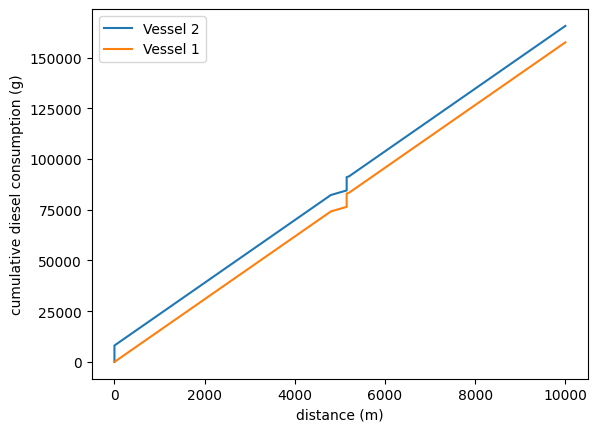

In [17]:
fig,ax = plt.subplots()
for obj_id, df_obj in df_eventtable_energy_fuel.groupby('object id'):
    dist_0 = df_obj['distance (m)'].shift(1)
    dist_0 = dist_0.fillna(0.)
    dist_cum_0 = dist_0.cumsum()
    dist_1 = df_obj['distance (m)']
    dist_cum_1 = dist_1.cumsum()
    df_obj['diesel_consumption_cum'] = df_obj['diesel_consumption (g)'].cumsum()
    diesel_consumption_cum_0 = df_obj['diesel_consumption_cum'].shift(1)
    diesel_consumption_cum_0 = diesel_consumption_cum_0.fillna(0.)
    diesel_consumption_cum_1 = df_obj['diesel_consumption_cum']
    time = pd.concat([dist_cum_0, dist_cum_1])
    consumption = pd.concat([diesel_consumption_cum_0,diesel_consumption_cum_1])
    obj_name = df_obj['object name'].mode()[0]
    df = pd.DataFrame(consumption.values, index=time, columns=[obj_name])
    df = df.sort_values(obj_name)
    df.plot(ax=ax)
ax.legend()
ax.set_ylabel('cumulative diesel consumption (g)')

And the consumption rate over time:

Text(0, 0.5, 'diesel consumption rate (g/s)')

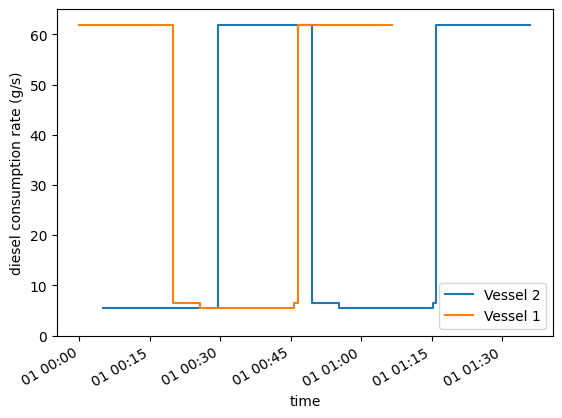

In [18]:
fig,ax = plt.subplots()
for obj_id, df_obj in df_eventtable_energy_fuel.groupby('object id'):
    obj_name = df_obj['object name'].mode()[0]
    diesel_consumption_0 = df_obj['diesel_consumption_s (g/s)'].shift(1)
    diesel_consumption_0 = diesel_consumption_0.bfill()
    diesel_consumption_1 = df_obj['diesel_consumption_s (g/s)'].shift(-1)
    diesel_consumption_1 = diesel_consumption_1.ffill()
    time = pd.concat([df_obj['start time'] - pd.Timedelta(nanoseconds=1),df_obj['stop time'] + pd.Timedelta(nanoseconds=1)])
    consumption = pd.concat([diesel_consumption_0,diesel_consumption_1])
    df = pd.DataFrame(consumption.values, index=time, columns=[obj_name])
    df = df.sort_index()
    df.plot(ax=ax)
ax.legend()
ax.set_xlabel('time')
ax.set_ylim(0,65)
ax.set_ylabel('diesel consumption rate (g/s)')

Text(0, 0.5, 'diesel consumption per m (g/m)')

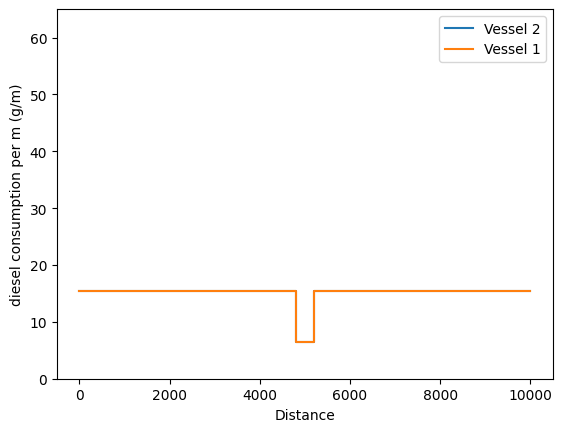

In [19]:
fig,ax = plt.subplots()
for obj_id, df_obj in df_eventtable_energy_fuel.groupby('object id'):
    obj_name = df_obj['object name'].mode()[0]
    dist_0 = df_obj['distance (m)'].cumsum().shift(1).fillna(0.)
    dist_cum_0 = dist_0.bfill()
    dist_1 = df_obj['distance (m)'].cumsum()+0.001
    dist_cum_1 = dist_1.ffill()
    diesel_consumption_0 = df_obj['diesel_consumption_m (g/m)'].shift(1)
    diesel_consumption_0 = diesel_consumption_0.bfill()
    diesel_consumption_1 = df_obj['diesel_consumption_m (g/m)'].shift(-1)
    diesel_consumption_1 = diesel_consumption_1.ffill()
    dist = pd.concat([dist_cum_0, dist_cum_1])
    consumption = pd.concat([diesel_consumption_0,diesel_consumption_1])
    df = pd.DataFrame(consumption.values, index=dist, columns=[obj_name])
    df = df.sort_index()
    df.plot(ax=ax)
ax.legend()
ax.set_xlabel('Distance')
ax.set_ylim(0,65)
ax.set_ylabel('diesel consumption per m (g/m)')

In [43]:
def create_edge_traffic_gdf(df_eventtable):

    first_cols = [
        'network_geometry',
        'waterway width (m)',
        ]

    sum_cols = [
        'distance (m)',
        'duration (s)',
        'total_energy (kWh)',
        'diesel_consumption (g)',
        'CO2_emission_total (g)',
        'PM10_emission_total (g)',
        'NOX_emission_total (g)'
    ]
    
    mean_cols = [
        'engine age (year)',
        'P_tot (kW)',
        'P_given (kW)',
        'P_installed (kW)'
    ]
    
    weighted_cols_t = [
        'diesel_consumption_s (g/s)',
        'CO2_emission_per_s (g/s)',
        'PM10_emission_per_s (g/s)',
        'NOX_emission_per_s (g/s)', 
    ]

    weighted_cols_m = [
        'diesel_consumption_m (g/m)',
        'CO2_emission_per_m (g/m)',
        'PM10_emission_per_m (g/m)',
        'NOX_emission_per_m (g/m)', 
    ]
  
    def weighted_avg(group, col, weight_col):
        weight_sum = group[weight_col].sum()
        if weight_sum == 0.:
            return 0.
        return (group[col] * group[weight_col]).sum() / weight_sum

    agg_dict = {col: 'sum' for col in sum_cols}
    agg_dict.update({col: 'first' for col in first_cols})
    agg_dict.update({col: 'mean' for col in mean_cols})
    agg_dict['object id'] = lambda x: list(pd.unique(x))
    
    df_eventtable['geom_key'] = df_eventtable['network_geometry'].apply(lambda g: g.wkt)
    grouped = df_eventtable.groupby('geom_key')
    df_edges = grouped.agg(agg_dict).reset_index()
    for col in weighted_cols_t:
        df_edges[col] = grouped.apply(lambda g: weighted_avg(g, col, 'duration (s)'), include_groups=False).values
    for col in weighted_cols_m:
        df_edges[col] = grouped.apply(lambda g: weighted_avg(g, col, 'distance (m)'), include_groups=False).values
    df_edges['nr vessels'] =  df_edges['object id'].apply(len)
    renaming_columns = {
        'nr vessels': 'nr_vessels',
        'distance (m)': 'total_distance_sailed (m)',
        'duration (s)': 'total_residence time (s)',
        'P_tot (kW)': 'average_P_tot (kW)',
        'P_given (kW)': 'average_P_given (kW)',
        'P_installed (kW)': 'average_P_installed (kW)',
        'engine age (year)': 'average_engine_age (year)',
        'total_energy (kWh)': 'total_energy_consumed (kWh)',
        'diesel_consumption (g)': 'total_diesel_consumed (g)',
        'CO2_emission_total (g)': 'total_CO2_emitted (g)',
        'PM10_emission_total (g)': 'total_PM10_emitted (g)',
        'NOX_emission_total (g)': 'total_NOX_emitted (g)',
        'diesel_consumption_s (g/s)': 'average_diesel_consumption_s (g/s)',
        'CO2_emission_per_s (g/s)': 'average_CO2_emission_per_s (g/s)',
        'PM10_emission_per_s (g/s)': 'average_PM10_emission_per_s (g/s)',
        'NOX_emission_per_s (g/s)': 'average_NOX_emission_per_s (g/s)',
        'diesel_consumption_m (g/m)': 'average_diesel_consumption_m (g/m)',
        'CO2_emission_per_m (g/m)': 'average_CO2_emission_per_m (g/m)',
        'PM10_emission_per_m (g/m)': 'average_PM10_emission_per_m (g/m)',
        'NOX_emission_per_m (g/m)': 'average_NOX_emission_per_m (g/m)',
        'network_geometry': 'geometry',
        'object id': 'vessel_ids',
    }
    df_edges = df_edges.rename(columns=renaming_columns)
    df_edges = df_edges[list(renaming_columns.values())]
    gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs = 'EPSG:4326')
    return gdf_edges

In [44]:
import geopandas as gpd
gdf_edges = create_edge_traffic_gdf(df_eventtable_energy_fuel)

In [46]:
gdf_edges

,nr_vessels,total_distance_sailed (m),total_residence time (s),average_P_tot (kW),average_P_given (kW),average_P_installed (kW),average_engine_age (year),total_energy_consumed (kWh),total_diesel_consumed (g),total_CO2_emitted (g),total_PM10_emitted (g),total_NOX_emitted (g),average_diesel_consumption_s (g/s),average_CO2_emission_per_s (g/s),average_PM10_emission_per_s (g/s),average_NOX_emission_per_s (g/s),average_diesel_consumption_m (g/m),average_CO2_emission_per_m (g/m),average_PM10_emission_per_m (g/m),average_NOX_emission_per_m (g/m),geometry,vessel_ids
0,2,600.0,583.153347,105.019493,105.019493,1750.0,1990.0,17.011797,3845.393753,12200.385635,6.804719,171.383957,6.594138,20.921402,0.011669,0.293892,6.408990,20.333976,0.011341,0.285640,"LINESTRING (-0.00135 0, 0.00135 0)","[32b939d2-ad65-481e-a79e-f57e45b12485, 1a6423d..."
1,2,100.0,97.192225,105.019492,105.019492,1750.0,1990.0,2.835299,640.898961,2033.397614,1.134120,28.563993,6.594138,20.921402,0.011669,0.293892,6.408990,20.333976,0.011341,0.285640,"LINESTRING (-0.0018 0, -0.00135 0)","[32b939d2-ad65-481e-a79e-f57e45b12485, 1a6423d..."
2,2,9600.0,2400.000000,984.662385,984.662385,1750.0,1990.0,656.441590,148383.878170,470781.577103,262.576636,6613.267151,61.826616,196.158990,0.109407,2.755528,15.456654,49.039748,0.027352,0.688882,"LINESTRING (-0.04492 0, -0.0018 0)","[32b939d2-ad65-481e-a79e-f57e45b12485, 1a6423d..."
3,2,100.0,97.192225,105.019492,105.019492,1750.0,1990.0,2.835299,640.898961,2033.397614,1.134120,28.563993,6.594138,20.921402,0.011669,0.293892,6.408990,20.333976,0.011341,0.285640,"LINESTRING (0.00135 0, 0.0018 0)","[32b939d2-ad65-481e-a79e-f57e45b12485, 1a6423d..."
4,2,9600.0,2400.000000,984.662385,984.662385,1750.0,1990.0,656.441590,148383.878170,470781.577103,262.576636,6613.267151,61.826616,196.158990,0.109407,2.755528,15.456654,49.039748,0.027352,0.688882,"LINESTRING (0.0018 0, 0.04492 0)","[32b939d2-ad65-481e-a79e-f57e45b12485, 1a6423d..."
5,1,0.0,1200.000000,87.500000,87.500000,1750.0,1990.0,29.166667,6592.914251,20917.518851,11.666667,293.837200,5.494095,17.431266,0.009722,0.244864,0.000000,0.000000,0.000000,0.000000,POINT (-0.00135 0),[1a6423dc-5af5-4f0e-ad9c-013ff5cd7628]
6,1,0.0,1200.000000,87.500000,87.500000,1750.0,1990.0,29.166667,6592.914251,20917.518851,11.666667,293.837200,5.494095,17.431266,0.009722,0.244864,0.000000,0.000000,0.000000,0.000000,POINT (0.00135 0),[32b939d2-ad65-481e-a79e-f57e45b12485]
7,1,0.0,1473.768898,87.500000,87.500000,1750.0,1990.0,35.820772,8097.026642,25689.657255,14.328309,360.873438,5.494095,17.431266,0.009722,0.244864,0.000000,0.000000,0.000000,0.000000,POINT (0.04492 0),[1a6423dc-5af5-4f0e-ad9c-013ff5cd7628]
